# Nordic day-ahead price covariance

Pairwise covariance and correlation of hourly day-ahead prices for every bidding zone in
`datasets/nordic_baltic_clean_hourly.parquet`, rendered as heat-shaded matrices.

The cleaned file carries twelve zones: NO1–NO5, SE1–SE4, DK1, DK2 and DE_LU. The Baltic zones were
dropped upstream despite the file name, and FI does not survive cleaning either. Every remaining
zone sits on CET/CEST, so `timestamp_local` aligns across all twelve without conversion.

In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.robust import mad

CLEAN = Path("datasets/nordic_baltic_clean_hourly.parquet")

# Zones roughly north to south, so the matrix blocks read cleanly.
ZONE_ORDER = ["NO1", "NO2", "NO3", "NO4", "NO5",
              "SE1", "SE2", "SE3", "SE4",
              "DK1", "DK2", "DE_LU"]

pd.set_option("display.max_columns", 40)

## 1. Load the price panel

The cleaned file is long-format but already hourly, gap-filled and DST-resolved, so the prices go
straight to a wide panel with a single pivot.

In [2]:
clean = pd.read_parquet(CLEAN, columns=["timestamp_local", "zone", "variable", "value"])

panel = (clean.loc[clean["variable"] == "price"]
              .pivot(index="timestamp_local", columns="zone", values="value")
              .sort_index())
panel = panel[[z for z in ZONE_ORDER if z in panel.columns]]

print(f"{panel.shape[0]:,} hourly rows x {panel.shape[1]} zones")
print(f"{panel.index.min()}  ->  {panel.index.max()}")
panel.tail()

85,440 hourly rows x 12 zones
2016-01-02 00:00:00  ->  2025-09-30 23:00:00


zone,NO1,NO2,NO3,NO4,NO5,SE1,SE2,SE3,SE4,DK1,DK2,DE_LU
timestamp_local,,,,,,,,,,,,
2025-09-30 19:00:00,69.96,88.10,9.32,2.88,62.35,29.53,7.79,193.57,231.30,357.77,357.35,370.082
2025-09-30 20:00:00,59.94,96.60,5.22,4.05,59.29,19.43,10.63,100.57,118.33,147.28,147.19,155.772
2025-09-30 21:00:00,52.99,82.87,4.93,4.20,58.54,17.67,9.67,88.25,102.48,116.04,116.01,124.400
2025-09-30 22:00:00,47.38,72.38,3.80,4.23,58.30,15.87,8.82,79.04,92.35,101.63,101.61,109.472
2025-09-30 23:00:00,43.98,67.62,7.47,5.14,54.94,13.86,8.67,63.18,73.62,92.54,92.48,101.310


## 2. Coverage and dispersion by zone

The diagonal of the covariance matrix is the square of `std` below, so this table is the reference
for reading the matrix. The three sample lengths matter: DK and NO run from 2016, DE_LU from
October 2018, and the SE zones only from December 2021.

In [3]:
coverage = pd.DataFrame({
    "obs": panel.count(),
    "first_hour": panel.apply(lambda s: s.first_valid_index()),
    "last_hour": panel.apply(lambda s: s.last_valid_index()),
    "mean": panel.mean(),
    "std": panel.std(),
    "min": panel.min(),
    "max": panel.max(),
})
coverage.index.name = "zone"

(coverage.style
    .format({"obs": "{:,.0f}", "mean": "{:,.2f}", "std": "{:,.2f}",
             "min": "{:,.2f}", "max": "{:,.2f}",
             "first_hour": "{:%Y-%m-%d %H:%M}", "last_hour": "{:%Y-%m-%d %H:%M}"})
    .background_gradient(cmap="Blues", subset=["std"])
    .set_caption("Hourly day-ahead prices, EUR/MWh"))

,obs,first_hour,last_hour,mean,std,min,max
zone,,,,,,,
NO1,"85,392",2016-01-04 00:00,2025-09-30 23:00,58.01,65.73,-61.84,799.97
NO2,"85,392",2016-01-04 00:00,2025-09-30 23:00,62.54,72.08,-61.84,898.25
NO3,"85,392",2016-01-04 00:00,2025-09-30 23:00,31.91,30.04,-14.93,590.00
NO4,"85,392",2016-01-04 00:00,2025-09-30 23:00,26.47,22.62,-24.06,504.80
NO5,"85,392",2016-01-04 00:00,2025-09-30 23:00,56.53,65.18,-21.66,799.97
SE1,"33,576",2021-12-02 00:00,2025-09-30 23:00,36.46,50.60,-60.04,590.00
SE2,"33,576",2021-12-02 00:00,2025-09-30 23:00,37.12,51.59,-60.04,590.00
SE3,"33,576",2021-12-02 00:00,2025-09-30 23:00,68.75,86.72,-60.04,799.97
SE4,"33,576",2021-12-02 00:00,2025-09-30 23:00,85.00,95.75,-60.04,799.97


## 3. Conditionally coloured covariance matrix

`DataFrame.cov` uses pairwise-complete observations, so each pair is estimated on every hour where
both zones quote. `axis=None` puts the whole matrix on one colour scale instead of shading each
column independently — that is what makes the blocks comparable across the table.

In [4]:
cov = panel.cov()
corr = panel.corr()

# Pairwise observation count behind each estimate.
present = panel.notna().astype("int64")
pair_obs = present.T @ present


def shade_matrix(matrix, *, cmap="Blues", fmt="{:,.0f}", caption=None, vmin=None, vmax=None):
    """Heat-shade a square matrix on one shared scale and outline the diagonal."""
    diagonal = pd.DataFrame(
        np.where(np.eye(len(matrix), dtype=bool), "border: 2px solid #0e1113;", ""),
        index=matrix.index, columns=matrix.columns,
    )
    return (matrix.style
            .background_gradient(cmap=cmap, axis=None, vmin=vmin, vmax=vmax)
            .apply(lambda _: diagonal, axis=None)
            .format(fmt)
            .set_caption(caption)
            .set_table_styles([
                {"selector": "caption",
                 "props": "caption-side: top; font-weight: 600; padding-bottom: 8px;"},
                {"selector": "th", "props": "font-weight: 500; text-align: center;"},
                {"selector": "td",
                 "props": "text-align: right; font-variant-numeric: tabular-nums;"},
            ]))


shade_matrix(cov, caption="Covariance of hourly day-ahead prices, (EUR/MWh)² — diagonal is variance")

zone,NO1,NO2,NO3,NO4,NO5,SE1,SE2,SE3,SE4,DK1,DK2,DE_LU
zone,,,,,,,,,,,,
NO1,"4,321","4,571",865,397,"4,240","2,271","2,422","6,065","6,566","4,639","4,483","5,961"
NO2,"4,571","5,196",759,298,"4,485","2,052","2,263","6,257","7,085","5,377","5,162","6,883"
NO3,865,759,903,552,872,"1,857","1,868","2,035","1,831",694,733,856
NO4,397,298,552,511,412,"1,057","1,045","1,092",927,223,259,279
NO5,"4,240","4,485",872,412,"4,249","2,295","2,442","5,950","6,401","4,530","4,365","5,845"
SE1,"2,271","2,052","1,857","1,057","2,295","2,560","2,541","2,716","2,486","2,026","2,109","1,887"
SE2,"2,422","2,263","1,868","1,045","2,442","2,541","2,661","2,843","2,666","2,225","2,309","2,077"
SE3,"6,065","6,257","2,035","1,092","5,950","2,716","2,843","7,521","7,521","6,900","7,132","6,727"
SE4,"6,566","7,085","1,831",927,"6,401","2,486","2,666","7,521","9,168","8,229","8,540","7,939"


## 4. The same matrix as correlation

Covariance magnitudes are driven by price level, so the volatile continental zones dominate the
shading above regardless of how tightly they actually move together. Correlation strips the scale
out, and that is where the market structure shows up.

In [5]:
shade_matrix(
    corr,
    fmt="{:.2f}",
    vmin=0.0, vmax=1.0,
    caption="Correlation of hourly day-ahead prices — diagonal is unity",
)

zone,NO1,NO2,NO3,NO4,NO5,SE1,SE2,SE3,SE4,DK1,DK2,DE_LU
zone,,,,,,,,,,,,
NO1,1.00,0.96,0.44,0.27,0.99,0.50,0.52,0.78,0.76,0.88,0.85,0.86
NO2,0.96,1.00,0.35,0.18,0.95,0.42,0.45,0.74,0.76,0.93,0.90,0.91
NO3,0.44,0.35,1.00,0.81,0.45,0.85,0.84,0.55,0.44,0.29,0.31,0.26
NO4,0.27,0.18,0.81,1.00,0.28,0.71,0.69,0.43,0.33,0.12,0.14,0.12
NO5,0.99,0.95,0.45,0.28,1.00,0.50,0.52,0.76,0.74,0.86,0.84,0.84
SE1,0.50,0.42,0.85,0.71,0.50,1.00,0.97,0.62,0.51,0.37,0.39,0.34
SE2,0.52,0.45,0.84,0.69,0.52,0.97,1.00,0.64,0.54,0.40,0.42,0.37
SE3,0.78,0.74,0.55,0.43,0.76,0.62,0.64,1.00,0.91,0.74,0.76,0.72
SE4,0.76,0.76,0.44,0.33,0.74,0.51,0.54,0.91,1.00,0.80,0.83,0.77


## 5. Observations behind each pair

Three different sample lengths meet in this matrix, so the pairwise counts are worth a glance before
reading too much into any block. Any pair involving an SE zone rests on the shortest sample.

In [6]:
shade_matrix(pair_obs, cmap="Greys", caption="Pairwise complete observations (hours)")

zone,NO1,NO2,NO3,NO4,NO5,SE1,SE2,SE3,SE4,DK1,DK2,DE_LU
zone,,,,,,,,,,,,
NO1,"85,392","85,392","85,392","85,392","85,392","33,576","33,576","33,576","33,576","85,392","85,392","61,344"
NO2,"85,392","85,392","85,392","85,392","85,392","33,576","33,576","33,576","33,576","85,392","85,392","61,344"
NO3,"85,392","85,392","85,392","85,392","85,392","33,576","33,576","33,576","33,576","85,392","85,392","61,344"
NO4,"85,392","85,392","85,392","85,392","85,392","33,576","33,576","33,576","33,576","85,392","85,392","61,344"
NO5,"85,392","85,392","85,392","85,392","85,392","33,576","33,576","33,576","33,576","85,392","85,392","61,344"
SE1,"33,576","33,576","33,576","33,576","33,576","33,576","33,576","33,576","33,576","33,576","33,576","33,576"
SE2,"33,576","33,576","33,576","33,576","33,576","33,576","33,576","33,576","33,576","33,576","33,576","33,576"
SE3,"33,576","33,576","33,576","33,576","33,576","33,576","33,576","33,576","33,576","33,576","33,576","33,576"
SE4,"33,576","33,576","33,576","33,576","33,576","33,576","33,576","33,576","33,576","33,576","33,576","33,576"


## 6. Strongest and weakest pairs

In [7]:
upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
pairs = (upper.rename_axis(index="zone_a", columns="zone_b")
              .stack()
              .dropna()          # drop the masked lower triangle and diagonal
              .rename("corr")
              .reset_index()
              .sort_values("corr", ascending=False, ignore_index=True))
pairs["cov"] = [cov.loc[a, b] for a, b in zip(pairs["zone_a"], pairs["zone_b"])]
pairs["obs"] = [pair_obs.loc[a, b] for a, b in zip(pairs["zone_a"], pairs["zone_b"])]

(pd.concat([pairs.head(5), pairs.tail(5)])
   .style
   .format({"corr": "{:.3f}", "cov": "{:,.0f}", "obs": "{:,.0f}"})
   .background_gradient(cmap="Blues", subset=["corr"], vmin=0.0, vmax=1.0)
   .hide(axis="index")
   .set_caption("Five most and five least correlated zone pairs"))

zone_a,zone_b,corr,cov,obs
NO1,NO5,0.990,"4,240","85,392"
DK1,DK2,0.975,"6,267","85,440"
SE1,SE2,0.973,"2,541","33,576"
NO1,NO2,0.965,"4,571","85,392"
DK1,DE_LU,0.963,"8,108","61,344"
NO3,DE_LU,0.264,856,"61,344"
NO2,NO4,0.183,298,"85,392"
NO4,DK2,0.144,259,"85,392"
NO4,DK1,0.123,223,"85,392"
NO4,DE_LU,0.117,279,"61,344"


## 7. The variance-stabilizing transformation LEAR applies

LEAR does not fit on prices directly. `_lear.py` scales both the target and the non-dummy
regressors with epftoolbox's `'Invariant'` scaler, which is a median/MAD standardisation followed by
`arcsinh`:

$$z = \operatorname{arcsinh}\!\left(\frac{p - \operatorname{median}(p)}{\operatorname{MAD}(p)}\right)$$

`MAD` here is `statsmodels.robust.mad`, which divides the median absolute deviation by 0.6745 so it
estimates the same scale as a standard deviation under normality. The scaler is fitted on a 2-D
`(days × 24)` array, so the median and MAD are computed **per delivery hour** — hour 03 gets its own
centre and scale, independent of hour 18. The reconstruction below reproduces that column-wise fit.

`arcsinh` is what does the stabilising work: it is near-linear inside roughly ±1 MAD and grows
logarithmically beyond, so ordinary hours pass through nearly untouched while spikes are compressed.
Unlike a log transform it is defined for negatives, which day-ahead prices need.

One difference from a backtest: LEAR refits the scaler on each rolling calibration window. Here it is
fitted once on 2024 itself, so the panels show the transformation rather than any particular
recalibration.

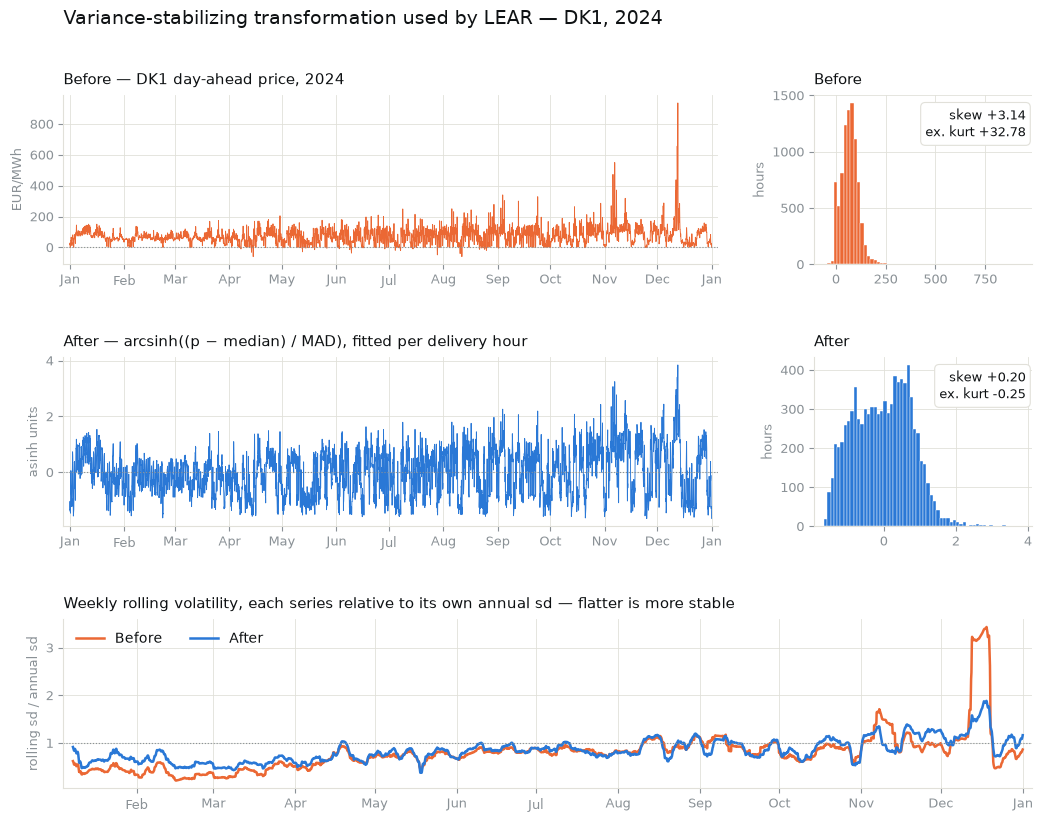

,before,after
skewness,3.14,0.20
excess kurtosis,32.78,-0.25
rolling-sd range,3.22,1.51


In [8]:
ZONE, YEAR = "DK1", "2024"
RAW_C, TRS_C = "#eb6834", "#2a78d6"          # before / after
INK, MUTED, GRID = "#0e1113", "#8a9196", "#e1e0d9"
WIN = 24 * 7                                  # one week, for the rolling panel

raw = panel.loc[YEAR, ZONE]

# epftoolbox InvariantScaler: median/MAD per delivery hour, then arcsinh.
Y = raw.to_numpy().reshape(-1, 24)
centre, scale = np.median(Y, axis=0), mad(Y, axis=0)
transformed = pd.Series(np.arcsinh((Y - centre) / scale).reshape(-1), index=raw.index)

fig, ax = plt.subplot_mosaic(
    [["raw", "hraw"], ["trs", "htrs"], ["roll", "roll"]],
    figsize=(12.5, 9), width_ratios=[3, 1],
    gridspec_kw={"hspace": 0.55, "wspace": 0.22},
)
fig.patch.set_facecolor("white")
for a in ax.values():
    a.set_facecolor("white")
    a.spines[["top", "right"]].set_visible(False)
    a.spines[["left", "bottom"]].set_color(GRID)
    a.tick_params(colors=MUTED, labelsize=9)
    a.grid(True, color=GRID, lw=0.6)
    a.set_axisbelow(True)

for key, series, colour, ylab, title in [
    ("raw", raw, RAW_C, "EUR/MWh", f"Before — {ZONE} day-ahead price, {YEAR}"),
    ("trs", transformed, TRS_C, "asinh units",
     "After — arcsinh((p − median) / MAD), fitted per delivery hour"),
]:
    a = ax[key]
    a.plot(series.index, series.to_numpy(), color=colour, lw=0.65)
    a.axhline(0, color=MUTED, lw=0.8, ls=":")
    a.set_ylabel(ylab, fontsize=9.5, color=MUTED)
    a.set_title(title, fontsize=11, color=INK, loc="left", pad=8)
    a.xaxis.set_major_locator(mdates.MonthLocator())
    a.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    a.margins(x=0.01)

for key, series, colour, title in [
    ("hraw", raw, RAW_C, "Before"),
    ("htrs", transformed, TRS_C, "After"),
]:
    a = ax[key]
    a.hist(series.to_numpy(), bins=60, color=colour, edgecolor="white", linewidth=0.3)
    a.set_ylabel("hours", fontsize=9.5, color=MUTED)
    a.set_title(title, fontsize=11, color=INK, loc="left", pad=8)
    a.annotate(f"skew {series.skew():+.2f}\nex. kurt {series.kurt():+.2f}",
               xy=(0.97, 0.93), xycoords="axes fraction", ha="right", va="top",
               fontsize=9.5, color=INK,
               bbox=dict(boxstyle="round,pad=.35", fc="white", ec=GRID, lw=0.8))

a = ax["roll"]
for series, colour, label in [(raw, RAW_C, "Before"), (transformed, TRS_C, "After")]:
    a.plot(series.index, (series.rolling(WIN).std() / series.std()).to_numpy(),
           color=colour, lw=1.8, label=label)
a.axhline(1, color=MUTED, lw=0.8, ls=":")
a.set_ylabel("rolling sd / annual sd", fontsize=9.5, color=MUTED)
a.set_title("Weekly rolling volatility, each series relative to its own annual sd — "
            "flatter is more stable", fontsize=11, color=INK, loc="left", pad=8)
a.xaxis.set_major_locator(mdates.MonthLocator())
a.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
a.margins(x=0.01)
for text in a.legend(frameon=False, fontsize=10, loc="upper left", ncol=2).get_texts():
    text.set_color(INK)

fig.suptitle(f"Variance-stabilizing transformation used by LEAR — {ZONE}, {YEAR}",
             fontsize=13.5, color=INK, x=0.125, ha="left", y=0.975)
plt.show()

spread = lambda s: ((s.rolling(WIN).std() / s.std()).max()
                    - (s.rolling(WIN).std() / s.std()).min())
pd.DataFrame({
    "before": [raw.skew(), raw.kurt(), spread(raw)],
    "after": [transformed.skew(), transformed.kurt(), spread(transformed)],
}, index=["skewness", "excess kurtosis", "rolling-sd range"]).round(2)

## 8. Persist the matrices

In [9]:
cov.round(2).to_csv("datasets/price_covariance_matrix.csv")
corr.round(4).to_csv("datasets/price_correlation_matrix.csv")